# Examine relative contribution of fixed and variable processes

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import pytensor
import pytensor.tensor as pt
import pingouin as pg

from devreact import figures
from devreact import model

model_name = 'neural-dual-v7'

fig_dir = Path(os.environ['REMIND_FIGURES']) / 'model' / model_name

%matplotlib inline
figures.set_style()

## Get data and parameter estimates from the sample trace

In [2]:
trace = az.from_netcdf(fig_dir / 'trace.nc')

In [3]:
# get relevant quantitites from the trace
post = trace.posterior
sind = trace.constant_data['subject_index']
s = 1
τ = post['τ'].to_numpy()
A = post['A'].to_numpy()
b = post['b'].isel(subject=sind).to_numpy()

v1 = post['v1_trial'].to_numpy()
v2 = post['v2_trial'].to_numpy()
r = post['r'].to_numpy()
v3 = post['v3'].isel(subject=sind).to_numpy()
v4 = post['v4'].isel(subject=sind).to_numpy()

n = trace.constant_data['n'].to_numpy()
rmat = trace.observed_data['response'].to_numpy()

subject = sind.to_numpy()
age = trace.constant_data['age'].isel(subject=sind).to_numpy()

In [4]:
# define a function to get relevant probabilities based on
# posterior parameter estimates
response_ = pt.specify_broadcastable(pt.specify_broadcastable(pt.dtensor4('r'), 0), 1)
n_ = pt.specify_broadcastable(pt.specify_broadcastable(pt.dtensor3('n'), 0), 1)

params = [
    pt.dscalar('s'),
    pt.specify_broadcastable(pt.dtensor3('τ'), 2),
    pt.specify_broadcastable(pt.dtensor3('A'), 2),
    pt.dtensor3('b'),
    pt.dtensor3('v1'),
    pt.dtensor3('v2'),
    pt.specify_broadcastable(pt.dtensor3('r'), 2),
    pt.dtensor3('v3'),
    pt.dtensor3('v4'),
]

p, c = model.pdf_dual(response_, n_, *params)
f = pytensor.function([response_, n_, *params], [p, *c])

In [5]:
# calculate probabilities
p, c1, c2, c3 = f(
    rmat[np.newaxis, np.newaxis, :, :],
    n[np.newaxis, np.newaxis, :],
    s, 
    τ[:, :, np.newaxis], 
    A[:, :, np.newaxis], 
    b, 
    v1, 
    v2, 
    r[:, :, np.newaxis], 
    v3, 
    v4,
)

In [6]:
import xarray as xr
ds = xr.Dataset(
    {
        "subject": (["trial"], subject),
        "age": (["trial"], age),
        "n": (["trial"], n),
        "response": (["trial"], rmat[:, 0]),
        "response_time": (["trial"], rmat[:, 1]),
        "c1": (["chain", "draw", "trial"], c1),
        "c2": (["chain", "draw", "trial"], c2),
    },
    coords={
        "chain": trace.posterior.coords["chain"],
        "draw": trace.posterior.coords["draw"],
        "trial": trace.constant_data.coords["trial"],
    }
)
ds

<xarray.Dataset> Size: 5GB
Dimensions:        (trial: 7317, chain: 4, draw: 10000)
Coordinates:
  * trial          (trial) int64 59kB 0 1 2 3 4 5 ... 7312 7313 7314 7315 7316
  * chain          (chain) int64 32B 0 1 2 3
  * draw           (draw) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    subject        (trial) int32 29kB 0 0 0 0 0 0 0 0 ... 73 73 73 73 73 73 73
    age            (trial) float64 59kB 8.024 8.024 8.024 ... 7.424 7.424 7.424
    n              (trial) int32 29kB 1 1 1 1 1 1 1 1 1 1 ... 2 2 2 2 2 2 2 2 2
    response       (trial) float64 59kB 0.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 0.0
    response_time  (trial) float64 59kB 1.383 3.46 5.003 ... 7.083 2.299 4.035
    c1             (chain, draw, trial) float64 2GB 0.0003517 ... 0.0005498
    c2             (chain, draw, trial) float64 2GB 0.01014 0.132 ... 0.1326

In [7]:
ds_correct = ds.where(ds["response"] == 1, drop=True)
ds_correct["c1_rel"] = ds_correct["c1"] / (ds_correct["c1"] + ds_correct["c2"])
ds_correct["c2_rel"] = ds_correct["c2"] / (ds_correct["c1"] + ds_correct["c2"])

In [8]:
m = ds_correct.groupby(["subject", "n"]).mean()
m

<xarray.Dataset> Size: 190MB
Dimensions:        (subject: 74, n: 2, chain: 4, draw: 10000)
Coordinates:
  * subject        (subject) float64 592B 0.0 1.0 2.0 3.0 ... 71.0 72.0 73.0
  * n              (n) float64 16B 1.0 2.0
  * chain          (chain) int64 32B 0 1 2 3
  * draw           (draw) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    age            (subject, n) float64 1kB 8.024 8.024 7.909 ... 7.424 7.424
    response       (subject, n) float64 1kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    response_time  (subject, n) float64 1kB 3.526 3.703 2.099 ... 3.028 5.196
    c1             (chain, draw, subject, n) float64 47MB 0.03854 ... 0.008895
    c2             (chain, draw, subject, n) float64 47MB 0.0979 ... 0.07881
    c1_rel         (chain, draw, subject, n) float64 47MB 0.2762 ... 0.1077
    c2_rel         (chain, draw, subject, n) float64 47MB 0.7238 ... 0.8923

## Test for age-related change in process proportions

In [9]:
from scipy import stats
def calc_linregress(x, y):
    res = stats.linregress(x, y)
    return res.slope

slope = xr.apply_ufunc(
    calc_linregress,
    m["age"],
    m["c1_rel"],
    input_core_dims=[['subject'], ['subject']],
    vectorize=True,
    output_dtypes=[np.float64],
)

In [10]:
az.hdi(slope.sel(n=1))

<xarray.Dataset> Size: 72B
Dimensions:  (hdi: 2)
Coordinates:
  * hdi      (hdi) <U6 48B 'lower' 'higher'
    n        float64 8B 1.0
Data variables:
    age      (hdi) float64 16B -0.003959 -0.0009601

In [11]:
az.hdi(slope.sel(n=2))

<xarray.Dataset> Size: 72B
Dimensions:  (hdi: 2)
Coordinates:
  * hdi      (hdi) <U6 48B 'lower' 'higher'
    n        float64 8B 2.0
Data variables:
    age      (hdi) float64 16B -0.0009296 0.00564

In [12]:
m_child = ds_correct.sel(trial=(ds_correct["age"] < 18)).groupby(["subject", "n"]).mean()
m_adult = ds_correct.sel(trial=(ds_correct["age"] > 18)).groupby(["subject", "n"]).mean()
m_adult

<xarray.Dataset> Size: 62MB
Dimensions:        (subject: 24, n: 2, chain: 4, draw: 10000)
Coordinates:
  * subject        (subject) float64 192B 4.0 5.0 6.0 7.0 ... 65.0 68.0 71.0
  * n              (n) float64 16B 1.0 2.0
  * chain          (chain) int64 32B 0 1 2 3
  * draw           (draw) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    age            (subject, n) float64 384B 19.58 19.58 20.36 ... 26.07 26.07
    response       (subject, n) float64 384B 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    response_time  (subject, n) float64 384B 1.63 3.227 1.481 ... 1.543 2.158
    c1             (chain, draw, subject, n) float64 15MB 0.02531 ... 0.3199
    c2             (chain, draw, subject, n) float64 15MB 0.6688 ... 0.1274
    c1_rel         (chain, draw, subject, n) float64 15MB 0.04419 ... 0.6871
    c2_rel         (chain, draw, subject, n) float64 15MB 0.9558 ... 0.3129

In [13]:
diff = m_adult.mean("subject") - m_child.mean("subject")
diff

<xarray.Dataset> Size: 3MB
Dimensions:        (n: 2, chain: 4, draw: 10000)
Coordinates:
  * n              (n) float64 16B 1.0 2.0
  * chain          (chain) int64 32B 0 1 2 3
  * draw           (draw) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    age            (n) float64 16B 16.9 16.9
    response       (n) float64 16B 0.0 0.0
    response_time  (n) float64 16B -0.7891 -0.8288
    c1             (chain, draw, n) float64 640kB 0.01576 0.07401 ... 0.07754
    c2             (chain, draw, n) float64 640kB 0.3027 0.07069 ... 0.07024
    c1_rel         (chain, draw, n) float64 640kB -0.04265 0.01995 ... 0.03789
    c2_rel         (chain, draw, n) float64 640kB 0.04265 -0.01995 ... -0.03789

In [14]:
az.hdi(diff.sel(n=1)["c1_rel"])

<xarray.Dataset> Size: 72B
Dimensions:  (hdi: 2)
Coordinates:
  * hdi      (hdi) <U6 48B 'lower' 'higher'
    n        float64 8B 1.0
Data variables:
    c1_rel   (hdi) float64 16B -0.06462 -0.01155

In [15]:
az.hdi(diff.sel(n=2)["c1_rel"])

<xarray.Dataset> Size: 72B
Dimensions:  (hdi: 2)
Coordinates:
  * hdi      (hdi) <U6 48B 'lower' 'higher'
    n        float64 8B 2.0
Data variables:
    c1_rel   (hdi) float64 16B -0.01321 0.1052

## Get mean relative process contributions for each subject

In [16]:
# package relevant quantities into a data frame
# and calculate relative probability of fixed and variable processes
avg = ds.mean(["chain", "draw"])
df = (
        pl.DataFrame(
        {
            'subject': subject,
            'Age': age,
            'n': n,
            'response': rmat[:, 0],
            'response_time': rmat[:, 1],
            'c1': avg["c1"].to_numpy(),
            'c2': avg["c2"].to_numpy(),
        }
    )
    .with_columns(
        pl.col('n').cast(pl.String).replace(
            {"1": "Direct", "2": "Indirect"}
        ).alias("Trial type"),
        pl.col("response").cast(pl.Int32).cast(pl.String).replace(
            {"0": "Incorrect", "1": "Correct"}
        ).alias("Response"),
    )
    .with_columns(
        pl.when(pl.col("Response") == "Correct")
        .then(pl.col("c1") / (pl.col("c1") + pl.col("c2")))
        .alias("Fixed-speed"),
        pl.when(pl.col("Response") == "Correct")
        .then(pl.col("c2") / (pl.col("c1") + pl.col("c2")))
        .alias("Variable-speed"),
    )
)

In [17]:
m = (
    df.filter(pl.col("Response") == "Correct")
    .group_by(["subject", "Age", "Trial type"])
    .agg(pl.col("Fixed-speed").mean(), pl.col("Variable-speed").mean())
    .unpivot(
        ["Fixed-speed", "Variable-speed"], 
        index=["subject", "Age", "Trial type"],
        variable_name="Process",
        value_name="Probability",
    )
)
m.head()

subject,Age,Trial type,Process,Probability
i32,f64,str,str,f64
56,10.716712,"""Direct""","""Fixed-speed""",0.0245
16,11.757808,"""Indirect""","""Fixed-speed""",0.50652
38,8.815616,"""Direct""","""Fixed-speed""",0.159835
65,29.805479,"""Direct""","""Fixed-speed""",0.092366
57,12.647945,"""Indirect""","""Fixed-speed""",0.36927


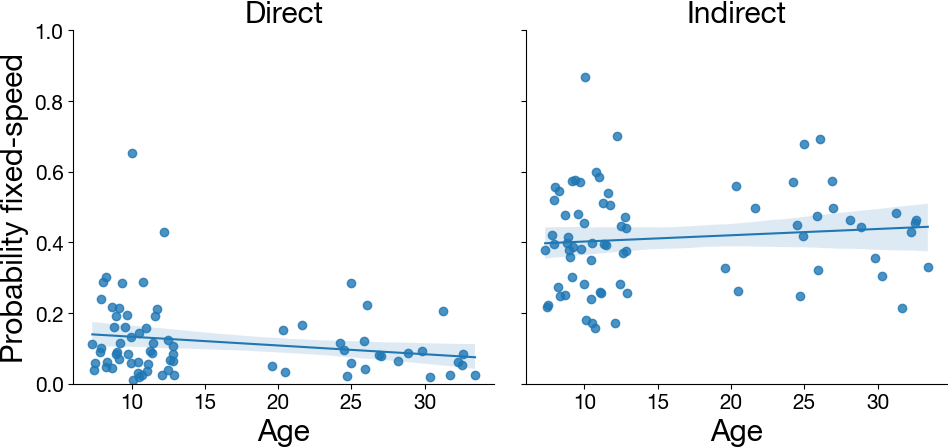

In [18]:
g = sns.lmplot(
    data=m.filter(pl.col("Process") == "Fixed-speed"),
    x="Age",
    y="Probability",
    col="Trial type",
    col_order=["Direct", "Indirect"],
)
g.set(ylabel="Probability fixed-speed", ylim=(0, 1))
g.set_titles(col_template="{col_name}");
g.savefig(fig_dir / "correct_process.pdf")

In [19]:
fixed_direct = m.filter(pl.col("Process") == "Fixed-speed", pl.col("Trial type") == "Direct")
pg.corr(fixed_direct["Age"], fixed_direct["Probability"])

,n,r,CI95,p_val,BF10,power
pearson,74,-0.198067,"[-0.41, 0.03]",0.090716,0.591,0.397913


In [20]:
children = fixed_direct.filter(pl.col("Age") < 18)
adults = fixed_direct.filter(pl.col("Age") >= 18)
pg.ttest(adults["Probability"], children["Probability"])

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-1.758663,68.92317,two-sided,0.083073,"[-0.08, 0.01]",0.366628,0.307711,0.932


In [24]:
fixed_indirect = m.filter(pl.col("Process") == "Fixed-speed", pl.col("Trial type") == "Indirect")
pg.corr(fixed_indirect["Age"], fixed_indirect["Probability"])

,n,r,CI95,p_val,BF10,power
pearson,74,0.105858,"[-0.13, 0.33]",0.369372,0.216,0.146587


In [22]:
children = fixed_indirect.filter(pl.col("Age") < 18)
adults = fixed_indirect.filter(pl.col("Age") >= 18)
pg.ttest(adults["Probability"], children["Probability"])

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,1.156291,52.668418,two-sided,0.25278,"[-0.03, 0.1]",0.271334,0.190119,0.447


In [23]:
%load_ext watermark
%watermark -v -iv

Python implementation: CPython
Python version       : 3.13.6
IPython version      : 9.12.0

arviz     : 0.23.4
devreact  : 0.1.0
matplotlib: 3.10.8
numpy     : 2.4.4
pandas    : 3.0.2
pingouin  : 0.6.1
polars    : 1.44.1
pytensor  : 2.38.2
scipy     : 1.17.1
seaborn   : 0.13.2
xarray    : 2026.2.0

